In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammetzahitaydn/hardhat-vest-dataset-v3")

print("Path to dataset files:", path)

100%|██████████| 4.21G/4.21G [00:54<00:00, 82.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2


In [ ]:
DATASET_PATH = '/root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2'

# Show contents of image and label directories
print("Training images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Validation images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

Training images: 17248
Validation images: 2438
Test images: 2455


In [ ]:
yaml_content = """
path: /root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2
train: images/train
val: images/val
nc: 3
names: ['hardhat', 'vest', 'person']
"""
# 📌 Check if the dataset folders and files exist
DATASET_PATH = '/root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2'

# Show contents of image and label directories
print("Training images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Validation images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

with open('hardhat.yaml', 'w') as f:
    f.write(yaml_content)  #YAML config file that YOLO needs to know how to train on your dataset.


print("✅ Updated YAML for dataset-v3 created!")

Training images: 17248
Validation images: 2438
Test images: 2455
✅ Updated YAML for dataset-v3 created!


In [ ]:
model = YOLO('yolov8n.pt')  # Using 'yolov8n.pt' for a pre-trained nano model
results = model.train(data='hardhat.yaml', epochs=10, imgsz=640)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=hardhat.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
metrics = model.val()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2337.0±953.2 MB/s, size: 221.8 KB)
val: Scanning /root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/labels/val.cache... 2438 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2438/2438 929.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 5.4it/s 28.1s
                   all       2438      21032      0.867      0.817      0.866      0.525
               hardhat       1782       6586      0.925      0.849      0.906      0.586
                  vest        406        870      0.796      0.744      0.812      0.533
                person        712      13576       0.88      0.857      0.879      0.457
Speed: 1.4ms preprocess, 3.8ms inference, 0.0ms loss, 1.4ms post

In [ ]:
results = model.predict(source=f"{DATASET_PATH}/images/test", save=True , verbose = False)

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/predict



image 1/1 /root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/images/test/a01079.jpg: 640x640 2 hardhats, 8.2ms
Speed: 1.8ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict7


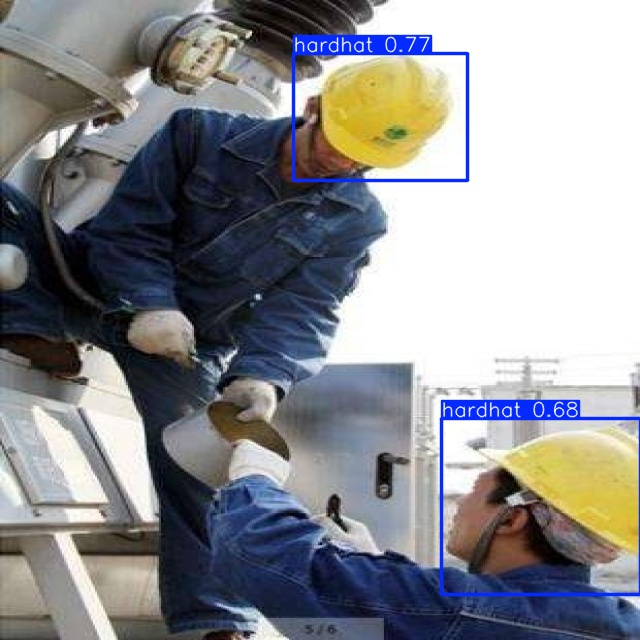

In [ ]:
import random
from IPython.display import Image, display
import os
from glob import glob
from ultralytics import YOLO
test_path = f"{DATASET_PATH}/images/test"
test_images = os.listdir(test_path)
random_image = random.choice(test_images)

image_path = f"{test_path}/{random_image}"

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(source=image_path, save=True)

predicted_path = glob("runs/detect/predict*/" + random_image)[0]

display(Image(filename=predicted_path))

In [ ]:
import shutil

src = "runs/detect/train/weights/best.pt"
dst = "hardhat_best.pt"

shutil.copy(src, dst)
print("Model saved as hardhat_best.pt")

Model saved as hardhat_best.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/hardhat_best.pt")

Saving download (2).jpeg to download (2).jpeg

0: 384x640 2 hardhats, 2 vests, 9.1ms
Speed: 1.8ms preprocess, 9.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


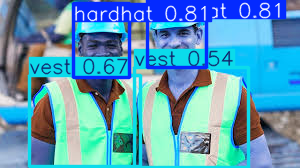

✔ Detection done!


In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import numpy as np

model = YOLO("/content/hardhat_best.pt")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(file_name)
img_array = np.array(img)

results = model(img_array)

results[0].show()

results[0].save()

print("✔ Detection done!")

Saving download (3).jpeg to download (3).jpeg

0: 640x448 1 vest, 1 person, 45.4ms
Speed: 1.9ms preprocess, 45.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)


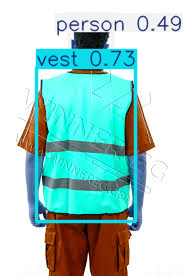

✔ Detection done!


In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import numpy as np

model = YOLO("/content/hardhat_best.pt")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(file_name)
img_array = np.array(img)

results = model(img_array)

results[0].show()

results[0].save()

print("✔ Detection done!")

Saving download (4).jpeg to download (4).jpeg

0: 640x448 1 hardhat, 10.2ms
Speed: 1.9ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


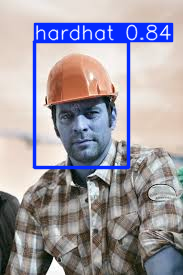

✔ Detection done!


In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import numpy as np

model = YOLO("/content/hardhat_best.pt")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(file_name)
img_array = np.array(img)

results = model(img_array)

results[0].show()

results[0].save()

print("✔ Detection done!")

Saving WhatsApp Image 2026-04-13 at 10.15.13 PM.jpeg to WhatsApp Image 2026-04-13 at 10.15.13 PM.jpeg

0: 640x576 1 vest, 2 persons, 43.5ms
Speed: 3.3ms preprocess, 43.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)


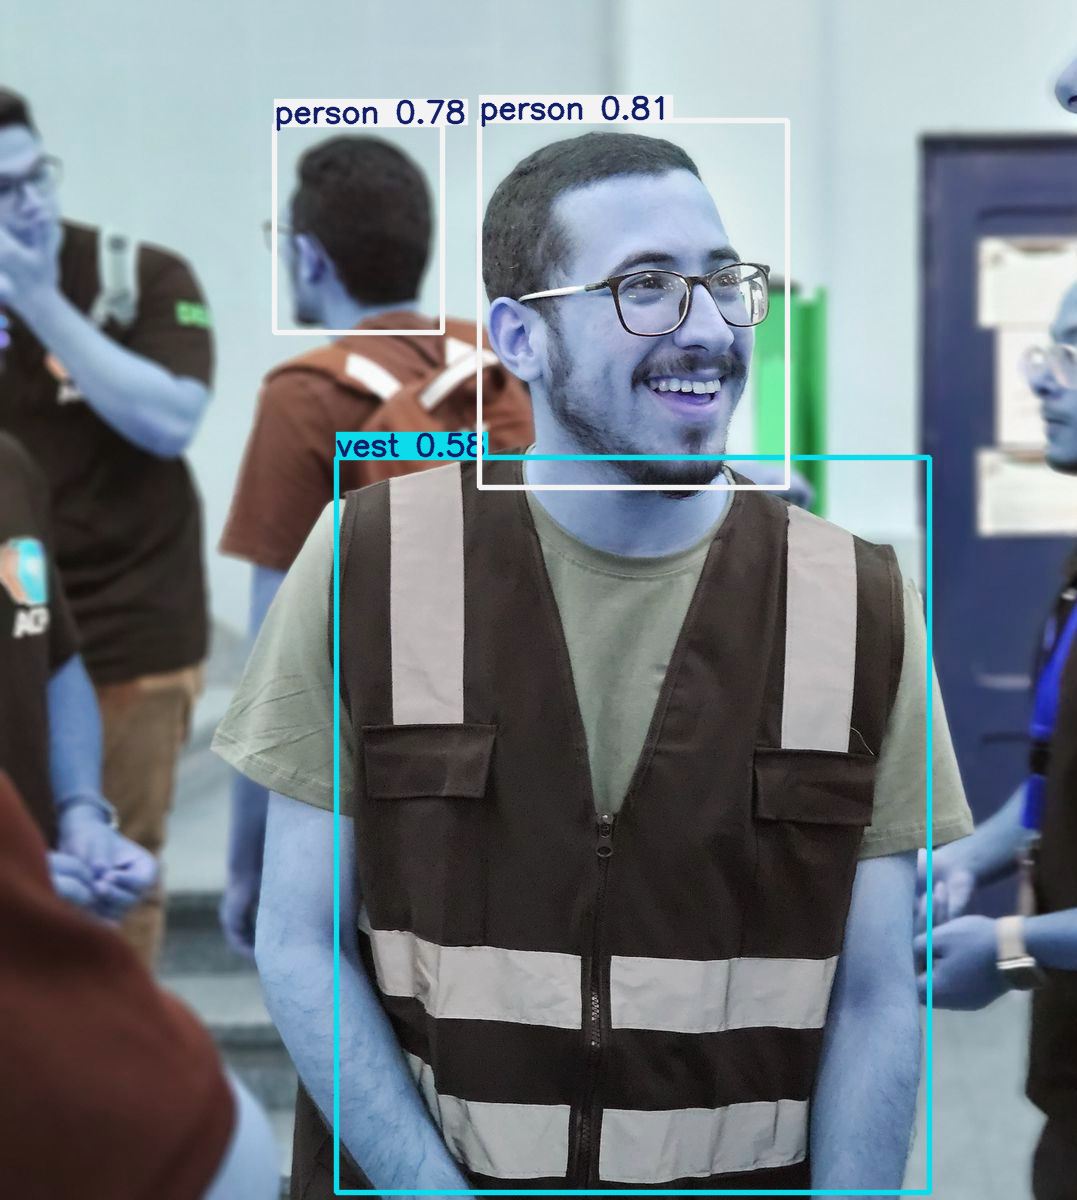

✔ Detection done!


In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import numpy as np

model = YOLO("/content/hardhat_best.pt")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(file_name)
img_array = np.array(img)

results = model(img_array)

results[0].show()

results[0].save()

print("✔ Detection done!")

Saving WhatsApp Image 2026-04-13 at 10.20.06 PM.jpeg to WhatsApp Image 2026-04-13 at 10.20.06 PM.jpeg

0: 640x480 1 hardhat, 8.2ms
Speed: 6.0ms preprocess, 8.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


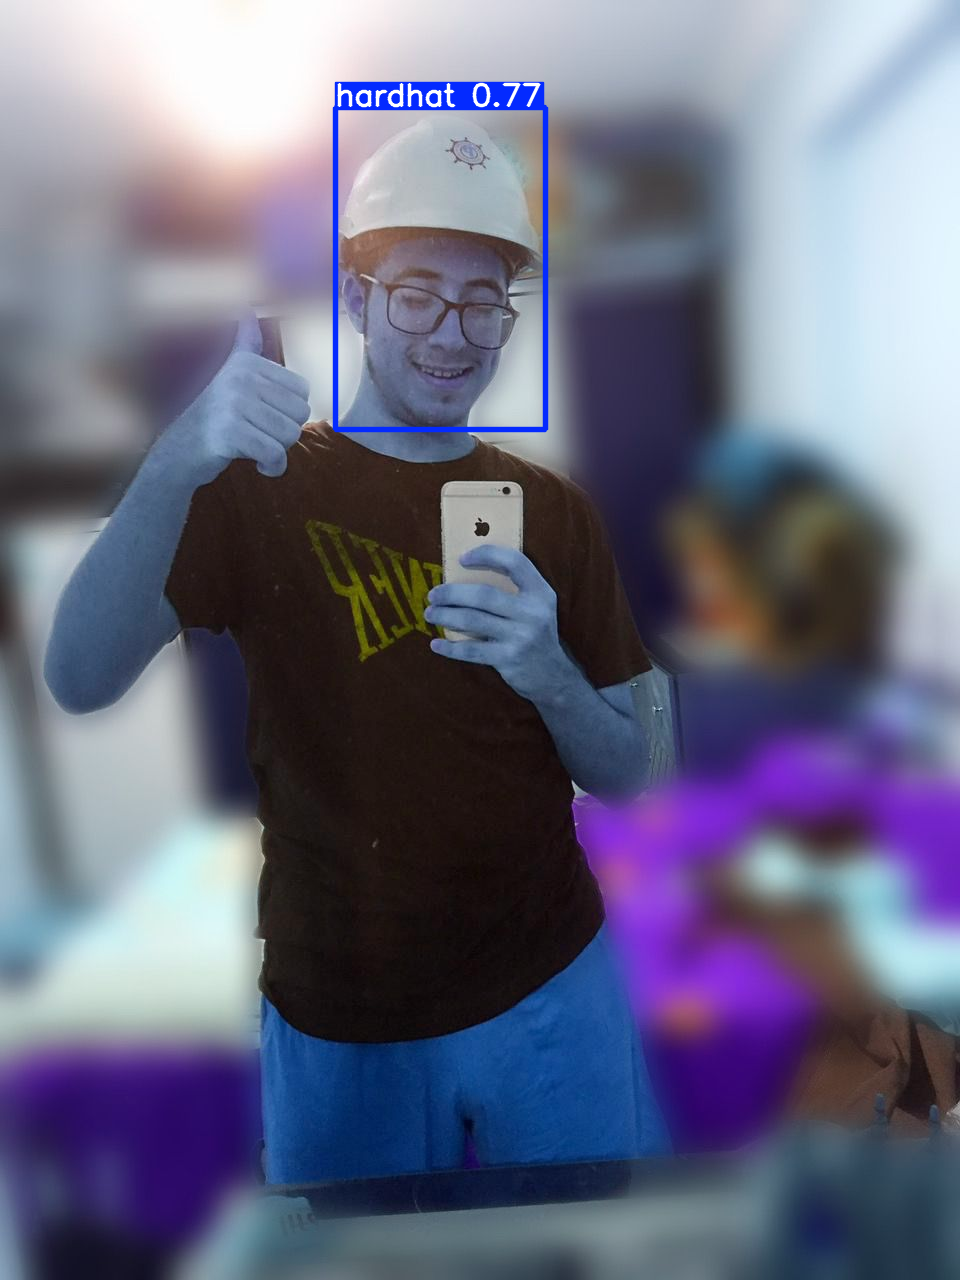

✔ Detection done!


In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import numpy as np

model = YOLO("/content/hardhat_best.pt")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(file_name)
img_array = np.array(img)

results = model(img_array)

results[0].show()

results[0].save()

print("✔ Detection done!")